In [10]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sna 
import warnings
import seaborn as sns
import numpy as np

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")


df=pd.read_csv(r'C:\Users\rajas\Documents\projets\p1.csv')
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


# 1. Inspection Générale des Données

In [3]:
df.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


In [19]:
df.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='object')

In [21]:
df['isFraud'].value_counts()

isFraud
0    6354407
1       8213
Name: count, dtype: int64

In [22]:
df['isFlaggedFraud'].value_counts()

isFlaggedFraud
0    6362604
1         16
Name: count, dtype: int64

In [24]:
df.shape

(6362620, 11)

# 2. Analyse Exploratoire des Données (EDA)

### Analyse du déséquilibre des classes (Class Imbalance)

**Objectif :** Calculer le pourcentage exact de transactions frauduleuses dans l'ensemble du dataset.

**Pourquoi :** * **Mesurer la rareté :** Ce calcul montre que la fraude est un événement extrêmement rare (environ 0,13 % des données).
**Anticiper le piège de l'Accuracy :** Si on ne connaît pas ce chiffre, on pourrait croire qu'un modèle avec 99 % de précision est bon, alors qu'il se contente de dire "pas de fraude" tout le temps.
**Justifier la stratégie :** Ce résultat mathématique prouve qu'il faudra forcer le modèle à accorder plus d'importance aux cas rares lors de l'entraînement.

In [4]:
round((df['isFraud'].value_counts()[1]/df.shape[0])*100,2)

np.float64(0.13)

### Pourquoi cette visualisation ?

**Objectif :** Afficher la répartition des types de transactions pour identifier comment l'argent circule globalement. [cite: 1]

**Pourquoi :**
* [cite_start]Cela permet de voir quelles catégories sont les **plus fréquentes** (comme `CASH_OUT` ou `PAYMENT`). [cite: 1]
* [cite_start]Cela aide à mieux cibler l'analyse avant de **zoomer** sur les catégories spécifiques qui contiennent de la fraude (`TRANSFER` et `CASH_OUT`). [cite: 1]

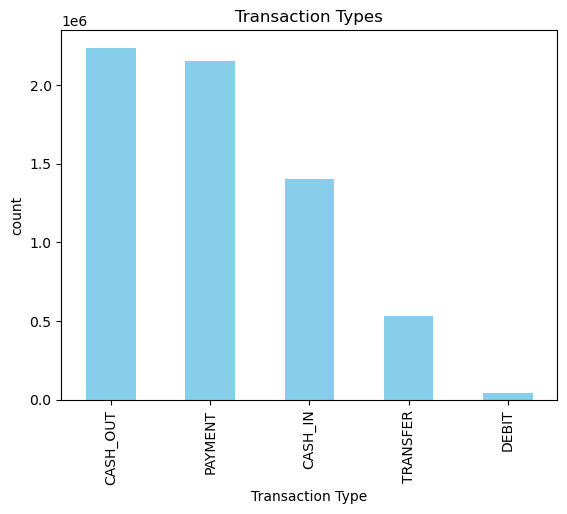

In [37]:
df["type"].value_counts().plot(kind="bar", title="Transaction Types", color="skyblue")
plt.xlabel("Transaction Type")
plt.ylabel("Count")
plt.show()

### Taux de fraude par type

**Objectif :** Identifier les catégories de transactions les plus à risque.

**Pourquoi :**
**Cibler le danger :** On confirme visuellement que la fraude se concentre uniquement sur `TRANSFER` et `CASH_OUT`. 
**Justifier le tri :** Cela explique pourquoi nous allons supprimer les autres types de transactions plus tard dans le projet. 
**Comprendre le vol :** On valide que les fraudeurs utilisent des méthodes spécifiques pour déplacer l'argent rapidement.

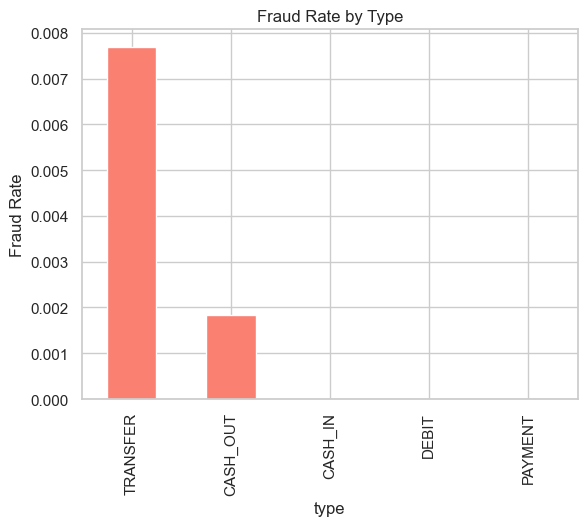

In [6]:
fraud_by_type = df.groupby("type")["isFraud"].mean().sort_values(ascending=False)

fraud_by_type.plot(kind="bar", title="Fraud Rate by Type", color="salmon")
plt.ylabel('Fraud Rate')
plt.show()

### Statistiques descriptives des montants

**Objectif :** Analyser la distribution des sommes d'argent transférées dans le dataset.

**Pourquoi :**
**Détecter les échelles :** On identifie rapidement le montant moyen, le minimum et surtout le maximum (qui peut atteindre des millions). 
**Repérer les anomalies :** Si l'écart entre la moyenne et le maximum est immense, cela suggère la présence d'outliers (valeurs extrêmes).
**Préparer le Scaling :** Ces chiffres confirment qu'une normalisation (StandardScaler) sera nécessaire car les écarts de montants sont trop vastes pour le modèle.

In [44]:
round(df['amount'].describe().astype(int),2)

count     6362620
mean       179861
std        603858
min             0
25%         13389
50%         74871
75%        208721
max      92445516
Name: amount, dtype: int64

### Transformation Logarithmique des Montants

**Objectif :** Appliquer une échelle logarithmique (`log1p`) à la colonne `amount` pour mieux visualiser les données.

**Pourquoi :**
* **Réduire l'impact des anomalies :** Les montants extrêmes (92 millions) écrasent le graphique standard. Le log permet de rapprocher les petites et les grandes valeurs.
**Rendre la distribution plus "normale" :** Cela aide à voir si la majorité des transactions se regroupent autour d'une certaine somme, ce qui est plus facile à interpréter pour l'œil humain et pour certains modèles.
**Visualiser la densité :** L'ajout de la courbe `kde=True` permet de lisser l'histogramme pour identifier les pics de fréquence des transactions. 

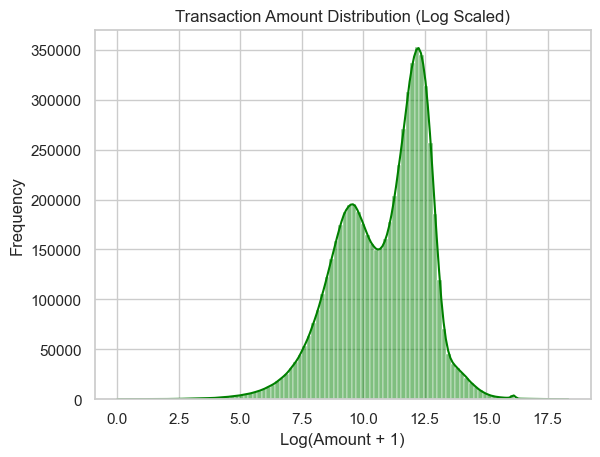

In [24]:
sns.histplot(np.log1p(df["amount"]), bins=100, kde=True, color="green")

plt.title("Transaction Amount Distribution (Log Scaled)")
plt.xlabel("Log(Amount + 1)")
plt.ylabel("Frequency")
plt.show()

### Comparaison des montants : Transactions Normales vs Fraudes

**Objectif :** Observer si le montant d'une transaction influence la probabilité qu'elle soit une fraude (pour les montants inférieurs à 50 000).

**Pourquoi :**
* **Identifier des seuils :** On cherche à voir si les fraudeurs privilégient des montants spécifiques pour passer sous les radars des banques.
* **Comparer les distributions :** Le boxplot montre la médiane et les écarts. Si la boîte "Fraude" est plus haute que la boîte "Normale", cela signifie que même pour de petites sommes, les fraudeurs ont un comportement différent.
* **Éliminer le "bruit" :** En filtrant à moins de 50 000, on retire les montants géants (outliers) pour se concentrer sur la zone où il y a le plus de transactions et voir les détails cachés.

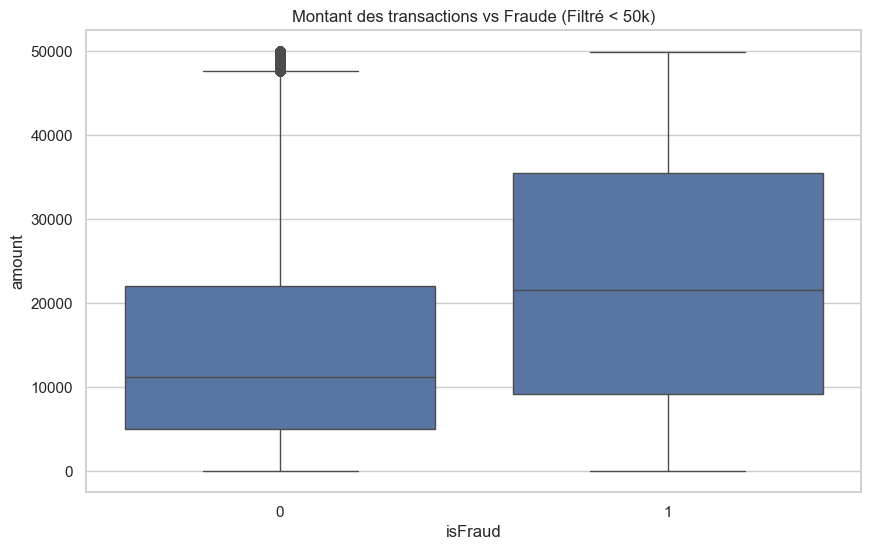

In [11]:
plt.figure(figsize=(10,6))
sns.boxplot(x='isFraud', y='amount', data=df[df['amount'] < 50000])
plt.title("Montant des transactions vs Fraude (Filtré < 50k)")
plt.show()

### Analyse temporelle de la fraude (Steps)

**Objectif :** Visualiser la fréquence des fraudes sur toute la durée du dataset (744 heures / 31 jours).

**Pourquoi :**
* **Identifier des cycles :** On cherche à voir si les fraudeurs agissent par vagues ou à des moments précis (par exemple, toutes les 24 heures).
* **Détecter la constance :** Contrairement aux transactions normales qui diminuent souvent la nuit, la fraude peut rester constante, ce qui en fait un indicateur suspect.
* **Vérifier la distribution :** Cela permet de s'assurer que les fraudes ne sont pas regroupées sur une seule journée, ce qui signifierait que le modèle doit apprendre des comportements qui durent dans le temps.

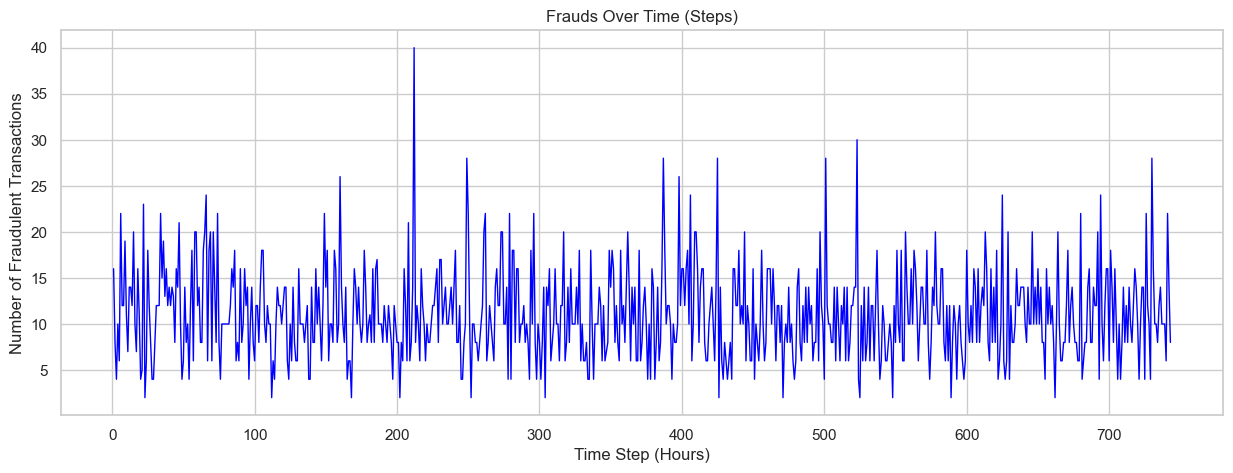

In [25]:
frauds_per_step = df[df['isFraud'] == 1]['step'].value_counts().sort_index()

plt.figure(figsize=(15, 5))
plt.plot(frauds_per_step.index, frauds_per_step.values, color='blue', linewidth=1)
plt.title("Frauds Over Time (Steps)")
plt.xlabel("Time Step (Hours)")
plt.ylabel("Number of Fraudulent Transactions")
plt.grid(True)
plt.show()

### Matrice de Corrélation des Variables Numériques

**Objectif :** Mesurer l'intensité du lien mathématique entre les différentes colonnes numériques et la variable cible `isFraud`.

**Pourquoi :**
**Identifier les relations fortes :** On cherche à voir si des variables comme `oldbalanceOrg` et `newbalanceOrig` sont fortement liées entre elles (ce qui est logique). 
* **Détecter les signaux de fraude :** On regarde si une colonne a un score de corrélation élevé avec `isFraud`. Cela indique au modèle que cette variable est un excellent indice pour prédire le vol. 
* **Éviter la redondance :** Si deux colonnes sont corrélées à 1.00 (identiques), on peut en supprimer une pour simplifier le modèle sans perdre d'information.

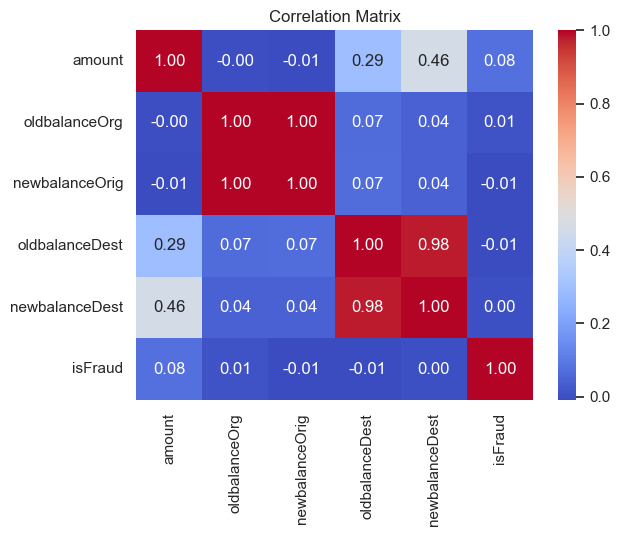

In [10]:

numeric_cols = ['amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'isFraud']
corr = df[numeric_cols].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Matrix")
plt.show()

# 3.Modélisation et Évaluation du Modèle

**Objectif :** Construire un pipeline de Machine Learning capable de détecter les fraudes et mesurer son efficacité.

**Pourquoi cette approche ?**

***Filtrage Ciblé :** On ne garde que `TRANSFER` et `CASH_OUT` car l'EDA a montré que la fraude est absente des autres types de transactions
***Feature Engineering :** On crée `diff_balance` pour capturer l'écart précis entre les soldes, ce qui aide le modèle à repérer les comptes vidés.
***Le Pipeline :** * `StandardScaler` : Harmonise les montants pour éviter que les gros chiffres ne faussent les calculs.
*`OneHotEncoder` : Transforme le texte (`type`) en données numériques exploitables par l'algorithme.
***Logistic Regression (`class_weight='balanced'`) :** Comme la fraude est très rare, on force le modèle à accorder autant d'importance aux fraudes qu'aux transactions normales pour ne pas les ignorer.

**Interprétation des résultats :**
* **Recall :** C'est notre capacité à attraper les voleurs. Un score élevé ici signifie que peu de fraudes nous échappent.
***Matrice de Confusion :** Elle permet de visualiser le nombre de fraudes stoppées par rapport aux clients innocents bloqués par erreur.

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay


df = pd.read_csv(r'C:\Users\rajas\Documents\projets\p1.csv')

In [ ]:
df_model = df[df['type'].isin(['TRANSFER', 'CASH_OUT'])].copy()
df_model['diff_balance_orig'] = df_model['oldbalanceOrg'] - df_model['newbalanceOrig']
df_model['diff_balance_dest'] = df_model['oldbalanceDest'] - df_model['newbalanceDest']
X = df_model.drop(['isFraud', 'nameOrig', 'nameDest', 'isFlaggedFraud'], axis=1)
y = df_model['isFraud']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
num_features = ['amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'diff_balance_orig', 'diff_balance_dest']
cat_features = ['type']
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(drop='first'), cat_features)])
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(class_weight='balanced', max_iter=1000))])

In [13]:
model_pipeline.fit(X_train, y_train)
y_pred = model_pipeline.predict(X_test)
print("--- Rapport de Classification ---")
print(classification_report(y_test, y_pred))
print("--- Matrice de Confusion ---")
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

NameError: name 'model_pipeline' is not defined

In [12]:
import joblib

joblib.dump(model_pipeline, 'fraud_detection_model.pickle')
print("Modèle exporté avec succès !")

NameError: name 'model_pipeline' is not defined

# 4. Interprétation des Résultats du Modèle

**Objectif :** Analyser l'efficacité réelle du détective virtuel face aux données de test.

### 1. L'Accuracy Globale : 94%
* **Constat :** Le modèle prend la bonne décision dans environ 94 % des cas au total.
* **Note :** Ce score élevé montre que l'algorithme a bien appris à distinguer les comportements normaux des comportements suspects.

### 2. Le Recall (Fraude) : 0.89 (89%)
* **Chiffre Clé :** C'est la capacité du modèle à attraper les voleurs.
* **Interprétation :** mon modèle détecte **89 % des fraudes réelles**. Sur les 2 496 fraudes du test, **2 214** ont été stoppées.
* **Impact :** Seul un petit nombre de fraudes passent entre les mailles du filet, ce qui protège les fonds de la banque.

### 3. La Precision (Fraude) : 0.04 (4%)
* **Le Compromis :** Ce chiffre est bas car le modèle est réglé pour être "très prudent".
* **Conséquence :** Il préfère suspecter un innocent (fausse alerte) plutôt que de laisser filer un criminel. En banque, on accepte souvent ce ratio pour garantir une sécurité maximale.

### 4. Conclusion de la Matrice de Confusion
La matrice confirme que la stratégie est payante : **la priorité est mise sur la détection **. Le coût d'une fraude non détectée est bien plus grave que le temps passé à vérifier une transaction légitime bloquée par erreur.

In [8]:
import streamlit as st
import pandas as pd
import joblib

model = joblib.load('fraud_detection_model.pickle')
st.title("Système de Détection de Fraude Bancaire")
st.write("Entrez les détails de la transaction pour analyse.")
st.sidebar.header("Paramètres de la Transaction")

type_trans = st.sidebar.selectbox("Type de Transaction", ['TRANSFER', 'CASH_OUT'])
amount = st.sidebar.number_input("Montant", min_value=0.0, value=1000.0)
oldbalanceOrg = st.sidebar.number_input("Solde Initial Origine", value=5000.0)
newbalanceOrig = st.sidebar.number_input("Nouveau Solde Origine", value=4000.0)
oldbalanceDest = st.sidebar.number_input("Solde Initial Destination", value=0.0)
newbalanceDest = st.sidebar.number_input("Nouveau Solde Destination", value=1000.0)


diff_balance_orig = oldbalanceOrg - newbalanceOrig
diff_balance_dest = oldbalanceDest - newbalanceDest


input_data = pd.DataFrame({
    'type': [type_trans],
    'amount': [amount],
    'oldbalanceOrg': [oldbalanceOrg],
    'newbalanceOrig': [newbalanceOrig],
    'oldbalanceDest': [oldbalanceDest],
    'newbalanceDest': [newbalanceDest],
    'diff_balance_orig': [diff_balance_orig],
    'diff_balance_dest': [diff_balance_dest]})


if st.button("Analyser la transaction"):
    prediction = model.predict(input_data)
    
    if prediction[0] == 1:
        st.error("🚨 ALERTE : Cette transaction est potentiellement FRAUDULEUSE !")
    else:
        st.success("✅ Transaction validée : Aucun risque détecté.")

2026-03-09 06:27:45.306 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-09 06:27:45.306 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-09 06:27:45.307 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-09 06:27:45.307 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-09 06:27:45.308 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-09 06:27:45.308 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-09 06:27:45.309 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-09 06:27:45.309 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar